In [3]:

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
import re
import textwrap

sns.set_palette("pastel")
sns.set_style("whitegrid")

In [4]:
# Load your cleaned file
df = pd.read_csv("awareness_scores_with_categories.csv")

In [47]:
print("\n=== Value Counts for Each Column ===")
for col in df.columns:
    print(df[col].value_counts(dropna=False).to_string())


=== Value Counts for Each Column ===
if_you_experience_symptoms_of_warning_signs,_which_specialist_would_you_consult?
Physician                                 3820
Neurologist                               1474
Orthopedic                                 447
ENT (Ear, Nose, and Throat specialist)     401
Yes                                         26
do_you_know_what_is_a_brain_stroke?
Yes      3882
No       2245
Maybe      41
how_soon_would_you_consult_a_specialist_after_experiencing_the_first_symptom?
Immediately                         2876
Within a day                        2512
Within a week                        627
I would not consult a specialist      71
Within a month                        43
Other                                 39
do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?
yes      4448
maybe    1052
no        668
do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?
yes      4437
maybe     

In [27]:
# score_columns = [
#     'score_confusion',
#     'score_numbness',
#     'score_nosebleed',
#     'score_vision',
#     'score_symptoms',
#     'score_advice',
#     'score_location',
#     'score_urgency',
#     'score_first_contact',
#     'score_action_first_symptom',
#     'score_know_stroke',
#     'score_specialist'
#     'score_risk'
# ]

# for score_col in score_columns:
#     for grp in df['awareness_category'].unique():
#         sub = df[df['awareness_category'] == grp]

#         correct = (sub[score_col] == 1).sum()
#         incorrect = (sub[score_col] == 0).sum()

#         plt.figure()

#         if correct + incorrect == 0:
#             # Case: No valid responses
#             plt.pie(
#                 [1],
#                 labels=['No valid correct / incorrect responses'],
#                 autopct='%1.1f%%'
#             )
#             plt.title(f'{grp} Awareness – {score_col}')
#         else:
#             # Case: Valid responses exist
#             plt.pie(
#                 [correct, incorrect],
#                 labels=['Correct', 'Incorrect'],
#                 autopct='%1.1f%%'
#             )
#             plt.title(f'{grp} Awareness – {score_col}')

#         plt.show()


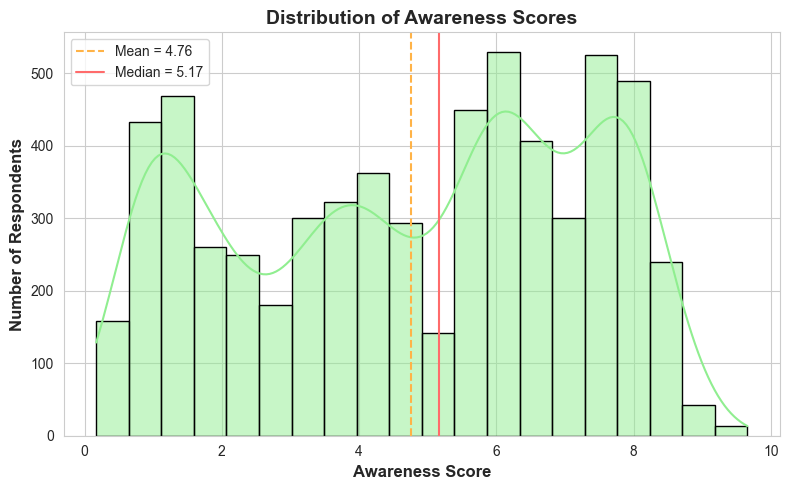

In [6]:
sns.set_style("whitegrid")
color = "#90EE90"  # pastel green for histogram, easy on eyes

plt.figure(figsize=(8,5))

# Histogram + KDE line
sns.histplot(df['awareness_score'], bins=20, kde=True, color=color, edgecolor='black')
plt.title("Distribution of Awareness Scores", fontsize=14, fontweight="bold")
plt.xlabel("Awareness Score", fontsize=12, fontweight="bold")
plt.ylabel("Number of Respondents", fontsize=12, fontweight="bold")

# Stat insight
mean = df['awareness_score'].mean()
median = df['awareness_score'].median()
plt.axvline(mean, color="#FFB347", linestyle='--', label=f"Mean = {mean:.2f}")
plt.axvline(median, color="#FF6B6B", linestyle='-', label=f"Median = {median:.2f}")

plt.legend()
plt.tight_layout()
plt.show()


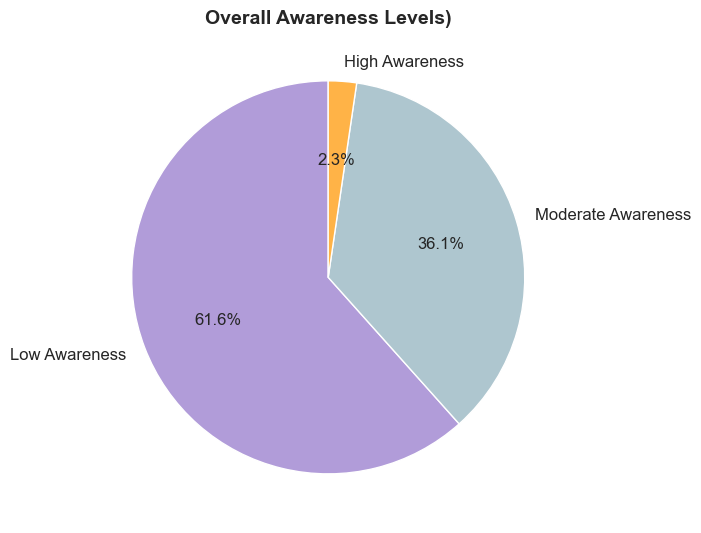

<Figure size 800x500 with 0 Axes>

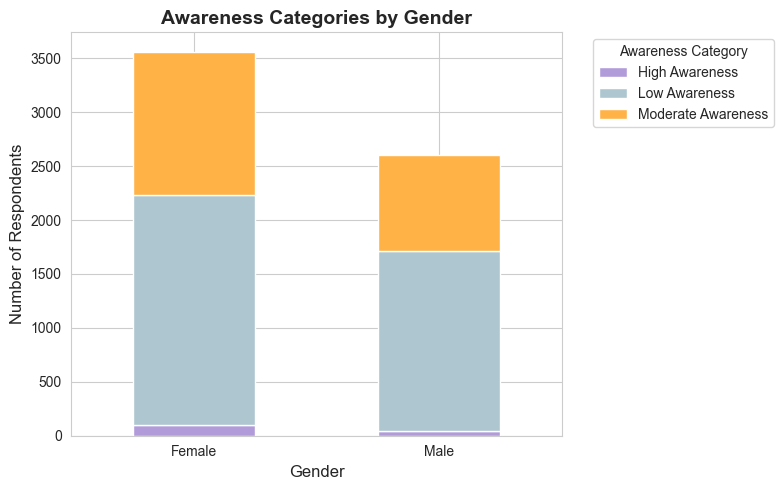

<Figure size 1000x500 with 0 Axes>

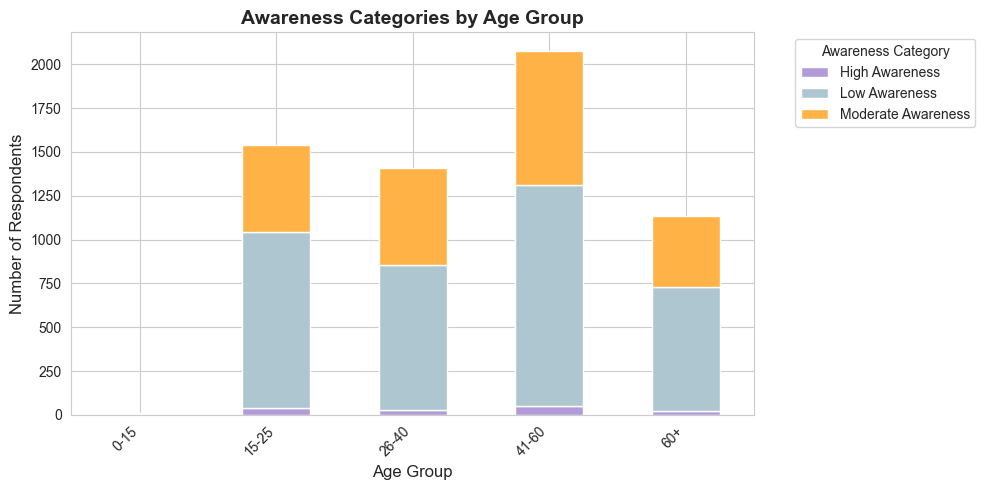

<Figure size 1000x600 with 0 Axes>

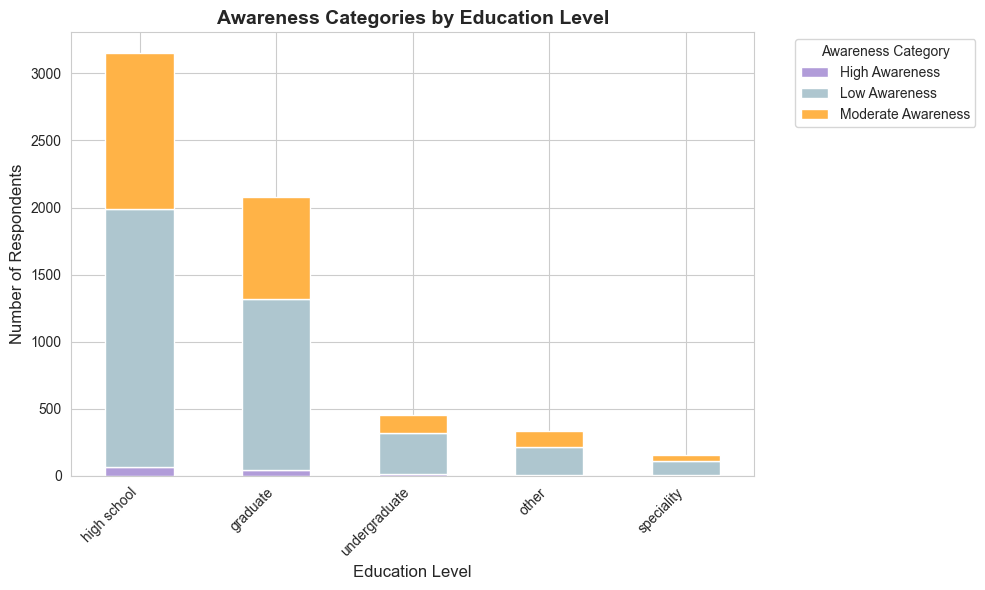

<Figure size 1000x600 with 0 Axes>

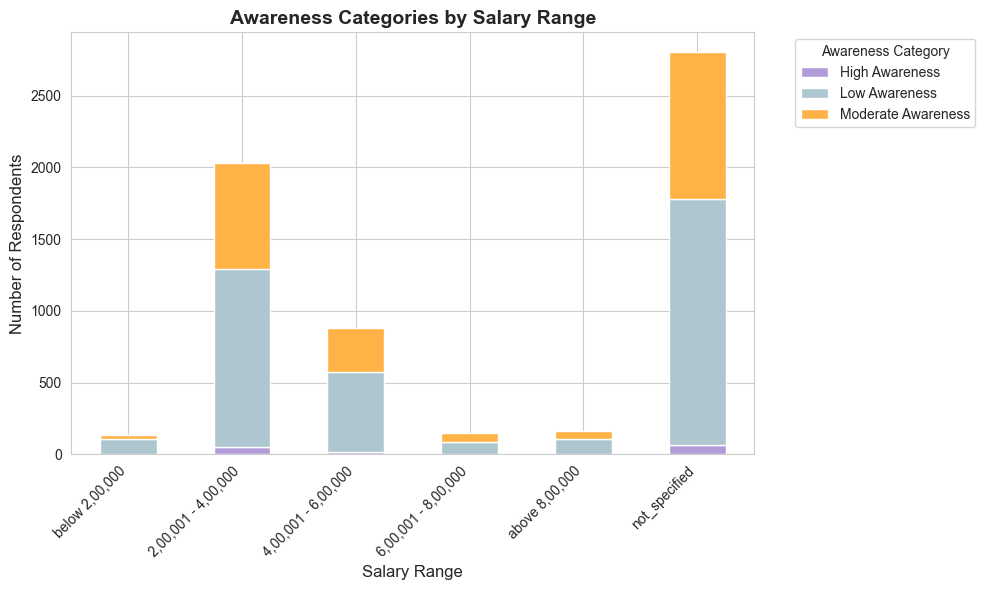

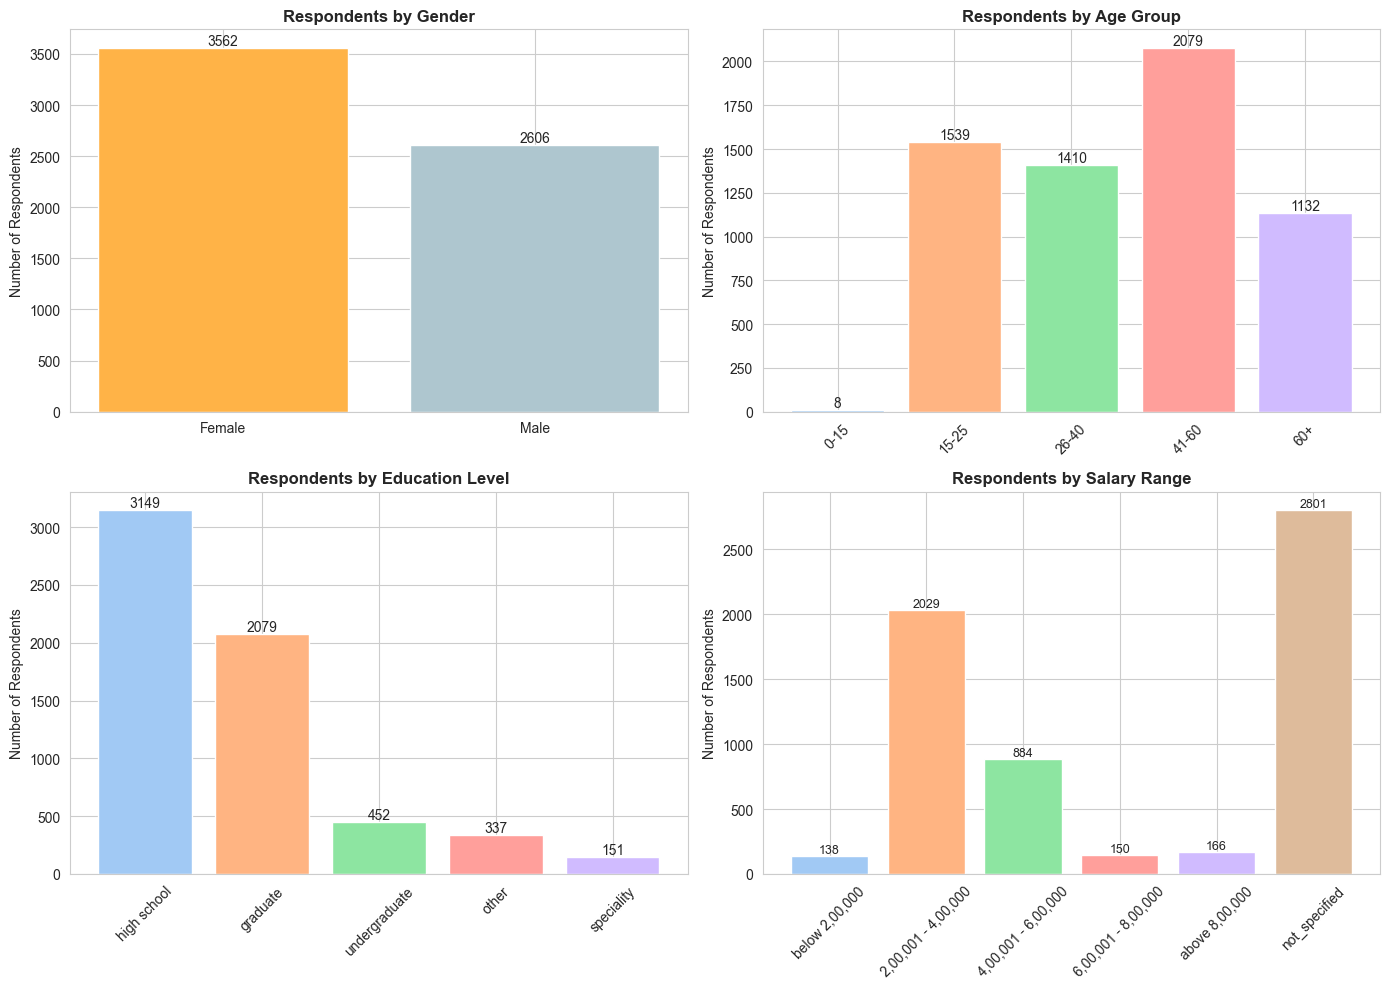


DEMOGRAPHIC SUMMARY TABLES

1. AWARENESS BY AGE GROUP (Count and Percentage)
----------------------------------------------------------------------
awareness_category High Awareness Low Awareness Moderate Awareness
age                                                               
0-15                     0 (0.0%)     6 (75.0%)          2 (25.0%)
15-25                   40 (2.6%)  1001 (65.0%)        498 (32.4%)
26-40                   30 (2.1%)   823 (58.4%)        557 (39.5%)
41-60                   49 (2.4%)  1263 (60.8%)        767 (36.9%)
60+                     24 (2.1%)   707 (62.5%)        401 (35.4%)

2. AWARENESS BY GENDER (Count and Percentage)
----------------------------------------------------------------------
awareness_category High Awareness Low Awareness Moderate Awareness
gender                                                            
Female                 102 (2.9%)  2127 (59.7%)       1333 (37.4%)
Male                    41 (1.6%)  1673 (64.2%)        892 (34.

In [49]:
# Define consistent colors
colors_awareness = ['#B19CD9', '#AEC6CF', '#FFB347']  # High, Low, Moderate

# ============================================
# 1. PIE CHART: Overall Awareness Levels
# ============================================
category_counts = df['awareness_category'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors_awareness, startangle=90, textprops={'fontsize': 12})
plt.title('Overall Awareness Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. STACKED BAR: Awareness by Gender
# ============================================
awareness_by_gender = pd.crosstab(df['gender'], df['awareness_category'])

plt.figure(figsize=(8, 5))
awareness_by_gender.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(8, 5))
plt.title('Awareness Categories by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 3. STACKED BAR: Awareness by Age Group
# ============================================
awareness_by_age = pd.crosstab(df['age'], df['awareness_category'])
# Reorder age groups logically
age_order = ['0-15', '15-25', '26-40', '41-60', '60+']
awareness_by_age = awareness_by_age.reindex(age_order)

plt.figure(figsize=(10, 5))
awareness_by_age.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 5))
plt.title('Awareness Categories by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 4. STACKED BAR: Awareness by Education Level
# ============================================
awareness_by_education = pd.crosstab(df['educational_level'], df['awareness_category'])
# Sort by total count
awareness_by_education = awareness_by_education.loc[awareness_by_education.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
awareness_by_education.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 6))
plt.title('Awareness Categories by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 5. STACKED BAR: Awareness by Salary Range
# ============================================
awareness_by_salary = pd.crosstab(df['salary'], df['awareness_category'])
# Logical order for salary
salary_order = ['below 2,00,000', '2,00,001 - 4,00,000', '4,00,001 - 6,00,000', 
                '6,00,001 - 8,00,000', 'above 8,00,000', 'not_specified']
awareness_by_salary = awareness_by_salary.reindex(salary_order)

plt.figure(figsize=(10, 6))
awareness_by_salary.plot(kind='bar', stacked=True, color=colors_awareness, figsize=(10, 6))
plt.title('Awareness Categories by Salary Range', fontsize=14, fontweight='bold')
plt.xlabel('Salary Range', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Awareness Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================
# 6. GROUPED BAR: Respondent Count by Demographics
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
gender_counts = df['gender'].value_counts()
axes[0, 0].bar(gender_counts.index, gender_counts.values, color=['#FFB347', '#AEC6CF'])
axes[0, 0].set_title('Respondents by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Respondents')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# Age Group
age_counts = df['age'].value_counts().reindex(age_order)
axes[0, 1].bar(age_counts.index, age_counts.values, color=sns.color_palette("pastel", 5))
axes[0, 1].set_title('Respondents by Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Respondents')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom')

# Education Level
education_counts = df['educational_level'].value_counts().sort_values(ascending=False)
axes[1, 0].bar(education_counts.index, education_counts.values, color=sns.color_palette("pastel", len(education_counts)))
axes[1, 0].set_title('Respondents by Education Level', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Respondents')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(education_counts.values):
    axes[1, 0].text(i, v, str(v), ha='center', va='bottom')

# Salary Range
salary_counts = df['salary'].value_counts().reindex(salary_order)
axes[1, 1].bar(salary_counts.index, salary_counts.values, color=sns.color_palette("pastel", 6))
axes[1, 1].set_title('Respondents by Salary Range', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Respondents')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(salary_counts.values):
    axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# 7. SUMMARY TABLES
# ============================================
print("\n" + "="*70)
print("DEMOGRAPHIC SUMMARY TABLES")
print("="*70)

print("\n1. AWARENESS BY AGE GROUP (Count and Percentage)")
print("-"*70)
awareness_by_age_pct = pd.crosstab(df['age'], df['awareness_category'], normalize='index') * 100
combined_age = awareness_by_age.copy()
for col in awareness_by_age.columns:
    combined_age[col] = awareness_by_age[col].astype(str) + ' (' + awareness_by_age_pct[col].round(1).astype(str) + '%)'
print(combined_age)

print("\n2. AWARENESS BY GENDER (Count and Percentage)")
print("-"*70)
awareness_by_gender_pct = pd.crosstab(df['gender'], df['awareness_category'], normalize='index') * 100
combined_gender = awareness_by_gender.copy()
for col in awareness_by_gender.columns:
    combined_gender[col] = awareness_by_gender[col].astype(str) + ' (' + awareness_by_gender_pct[col].round(1).astype(str) + '%)'
print(combined_gender)

print("\n3. AWARENESS BY EDUCATION LEVEL (Count and Percentage)")
print("-"*70)
awareness_by_education_pct = pd.crosstab(df['educational_level'], df['awareness_category'], normalize='index') * 100
combined_education = awareness_by_education.copy()
for col in awareness_by_education.columns:
    combined_education[col] = awareness_by_education[col].astype(str) + ' (' + awareness_by_education_pct[col].round(1).astype(str) + '%)'
print(combined_education)

print("\n4. AWARENESS BY SALARY RANGE (Count and Percentage)")
print("-"*70)
awareness_by_salary_pct = pd.crosstab(df['salary'], df['awareness_category'], normalize='index') * 100
combined_salary = awareness_by_salary.copy()
for col in awareness_by_salary.columns:
    combined_salary[col] = awareness_by_salary[col].astype(str) + ' (' + awareness_by_salary_pct[col].round(1).astype(str) + '%)'
print(combined_salary.reindex(salary_order))

print("\n" + "="*70)


Detected columns:
 awareness: symptom_awareness_score
 education: educational_level
 gender: gender
 age: age
 stroke multi: stroke_symptoms
 risk multi: risk_factors


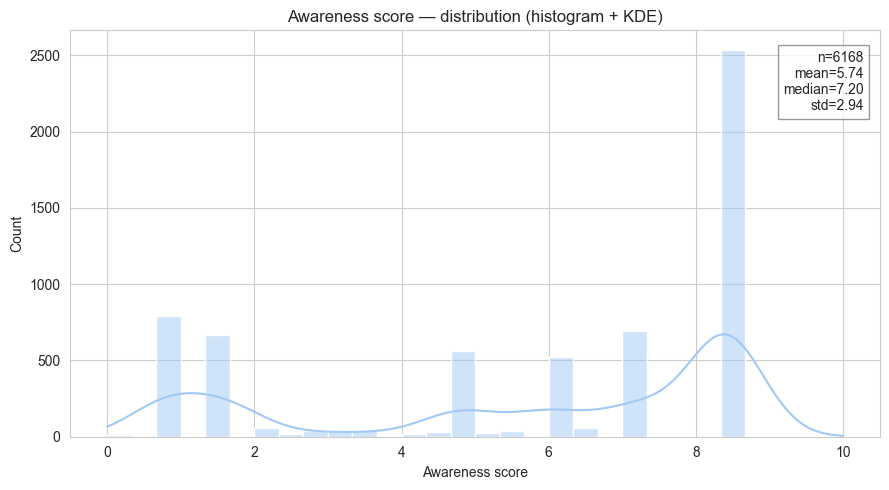

In [12]:


# Helpful: detect key columns (print what was found)
def find_col(df, keywords):
    for k in keywords:
        for c in df.columns:
            if k in c.lower():
                return c
    return None

aw_col = find_col(df, ["awareness","category","awareness_score","score"])
edu_col = find_col(df, ["educat","education"])
gender_col = find_col(df, ["gender","sex"])
age_col = find_col(df, ["age"])
multi_sym = find_col(df, ["stroke_symptoms","symptoms"])
multi_risk = find_col(df, ["risk_factors","risks"])

print("Detected columns:")
print(" awareness:", aw_col)
print(" education:", edu_col)
print(" gender:", gender_col)
print(" age:", age_col)
print(" stroke multi:", multi_sym)
print(" risk multi:", multi_risk)
# Step 1: awareness histogram + KDE + summary
aw = pd.to_numeric(df[aw_col], errors='coerce') if aw_col else None

plt.figure(figsize=(9,5))
if aw is not None and aw.dropna().size>0:
    sns.histplot(aw.dropna(), kde=True, stat="count", bins=30)
    plt.title("Awareness score — distribution (histogram + KDE)")
    plt.xlabel("Awareness score")
    plt.ylabel("Count")
    # summary text
    mean, median, std = aw.mean(), aw.median(), aw.std()
    plt.annotate(f"n={aw.dropna().size}\nmean={mean:.2f}\nmedian={median:.2f}\nstd={std:.2f}",
                 xy=(0.98,0.95), xycoords="axes fraction", ha="right", va="top",
                 bbox=dict(facecolor="white", edgecolor="gray", alpha=0.8))
else:
    plt.text(0.5,0.5,"No numeric awareness column available", ha='center')
plt.tight_layout()
plt.show()


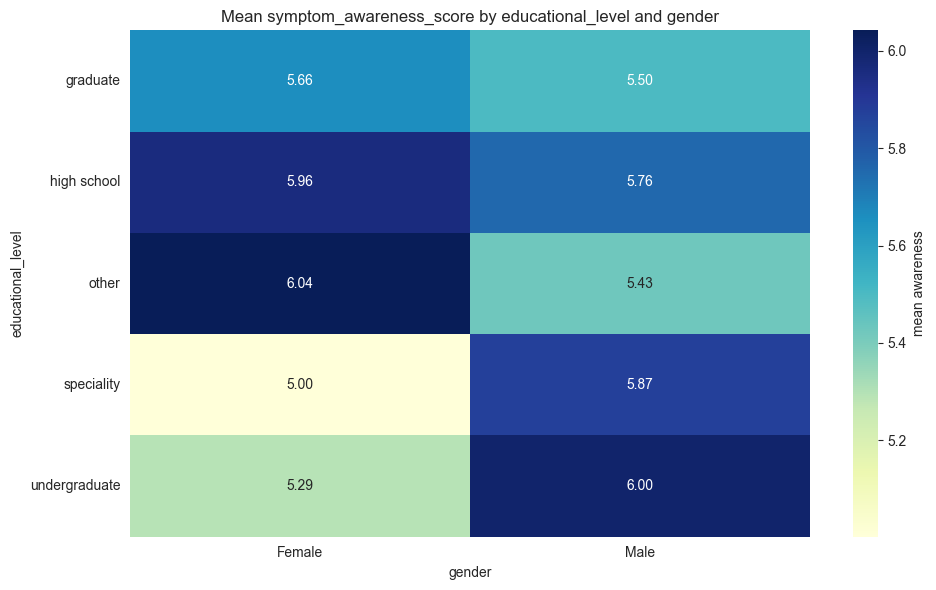

In [30]:
# Step 5: heatmap of mean awareness by education vs gender
if (edu_col in df.columns) and (gender_col in df.columns) and (aw is not None and aw.dropna().size>0):
    pivot = df.pivot_table(values=aw_col, index=edu_col, columns=gender_col, aggfunc='mean')
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label':'mean awareness'})
    plt.title(f"Mean {aw_col} by {edu_col} and {gender_col}")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Missing columns for the education x gender heatmap.")


Categorical (category-type) columns:
- if_you_experience_symptoms_of_warning_signs,_which_specialist_would_you_consult?
- do_you_know_what_is_a_brain_stroke?
- how_soon_would_you_consult_a_specialist_after_experiencing_the_first_symptom?
- do_you_think_sudden_confusion_,trouble_speaking_or_understanding_speech_is_a_stroke_symptom?
- do_you_think_sudden_numbness_or_weakness_of_face,_arm_or_leg_is_a_symptom_of_stroke?
- do_you_think_sudden_nosebleed_is_a_stroke_of_symptom?
- do_you_think_trouble_seeing_in_one_or_both_the_eyes_is_a_stroke_symptom?
- age
- gender
- educational_level
- salary
- first_contact_after_experiencing_symptom
- how_soon_treatment_should_be_taken_after_noticing_symptoms
- where_to_go_after_experiencing_symptoms_of_brain_stroke
- stroke_symptoms
- risk_factors
- what_advice_would_you_give_for_someone_experiencing_stroke_symptoms
- awareness_category
- awareness_specialist
- awareness_know_stroke
- awareness_action_first_symptom
- awareness_symptom_checklist
- awarene

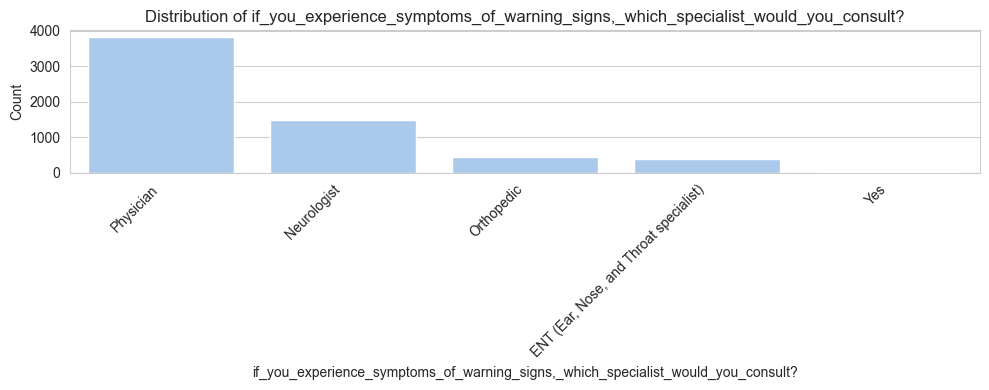

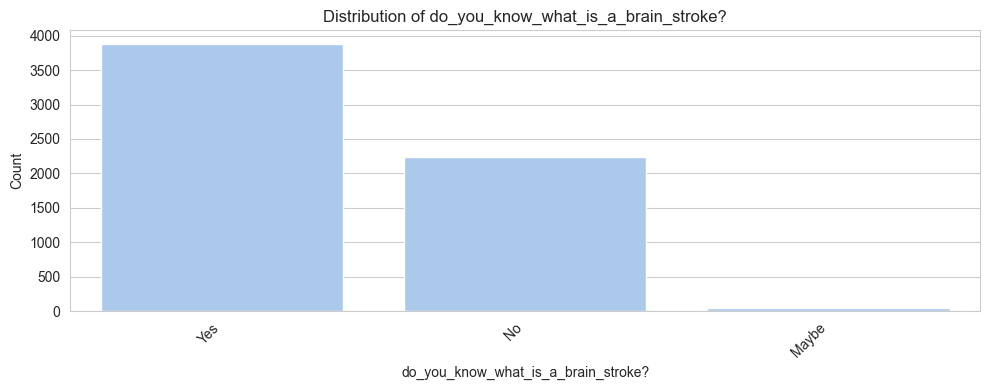

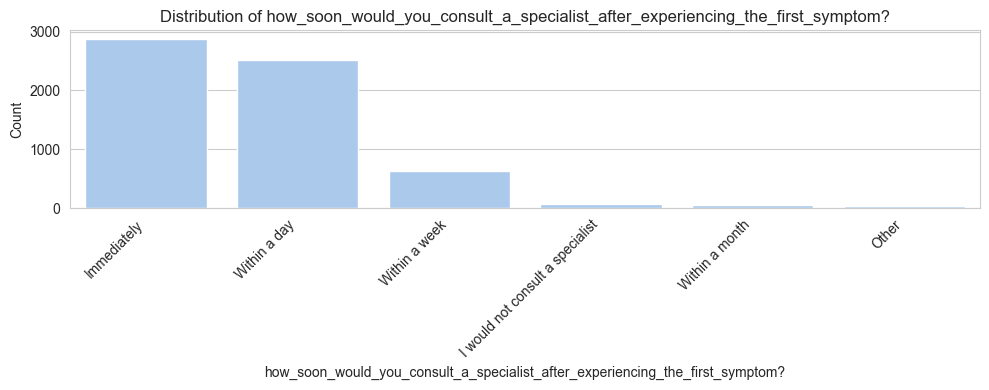

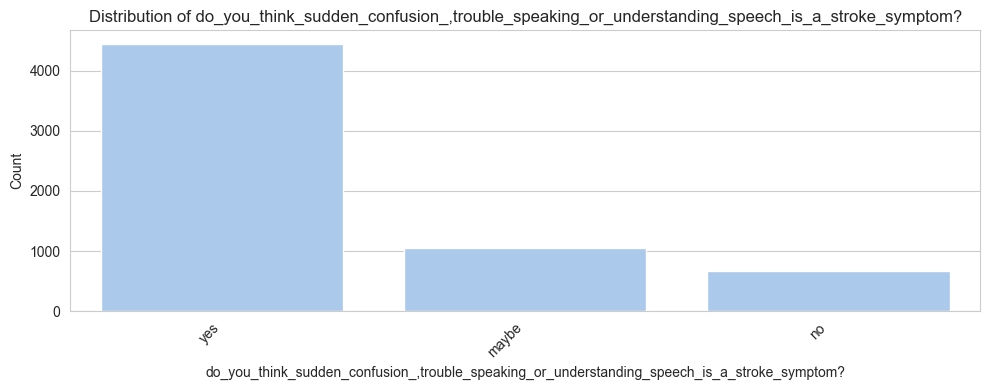

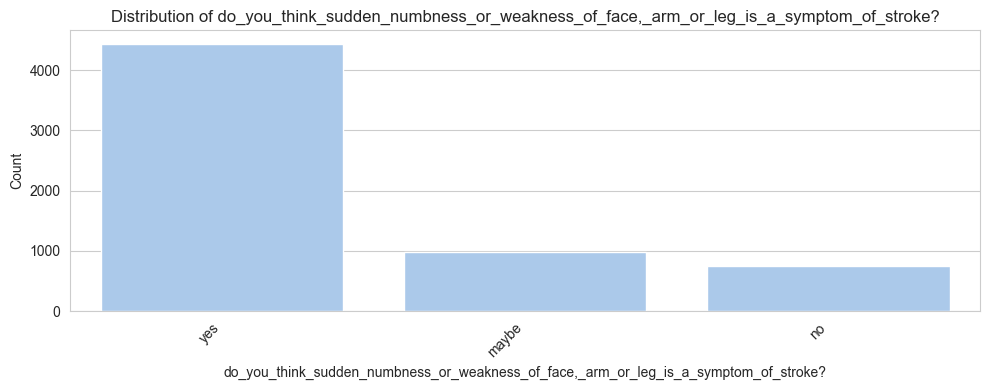

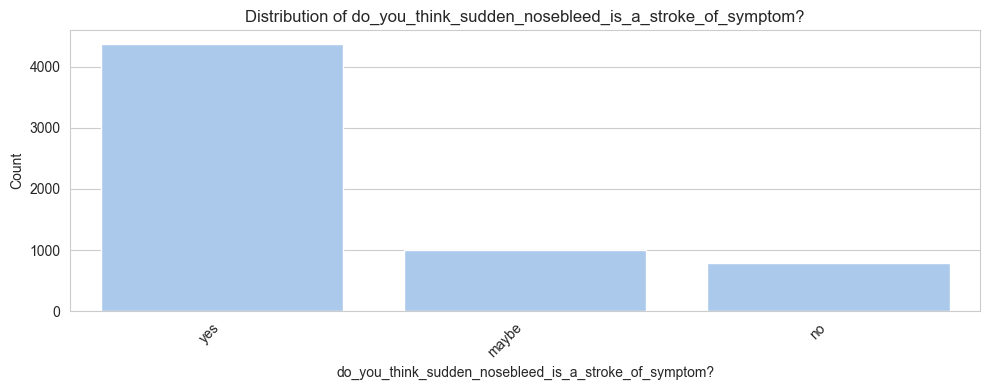

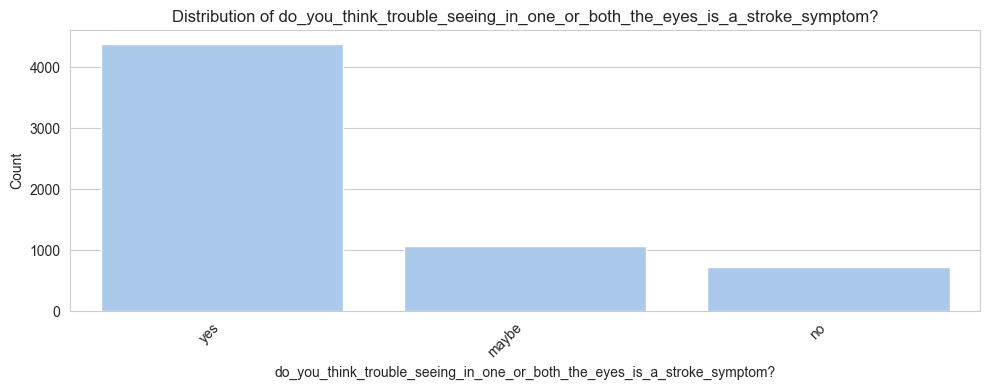

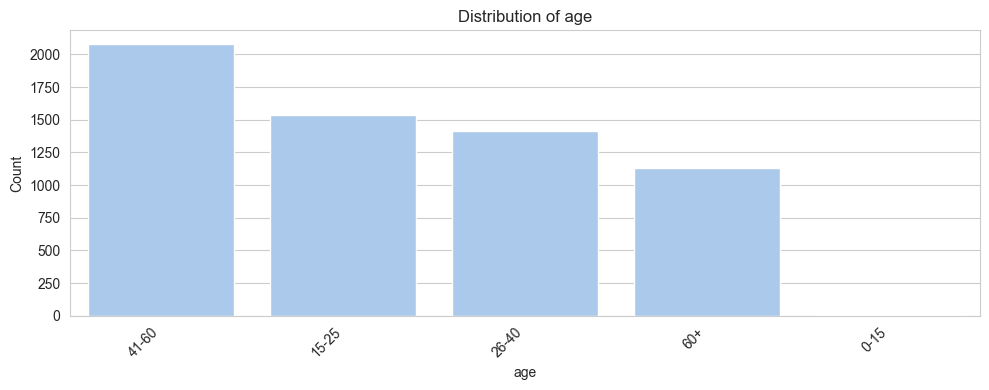

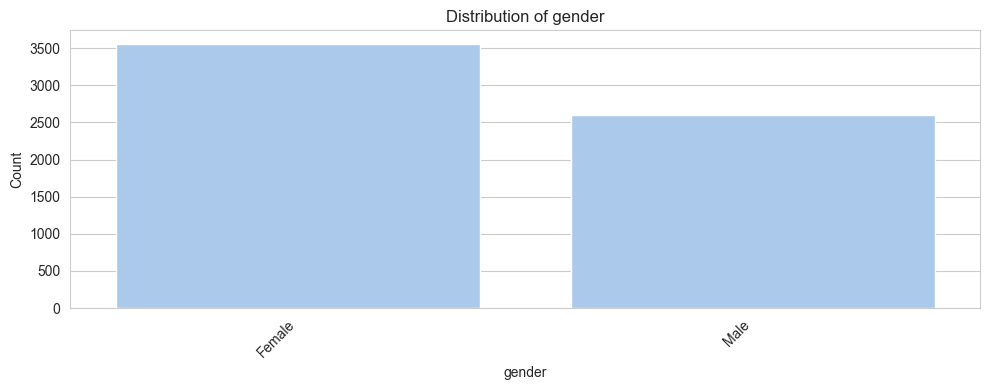

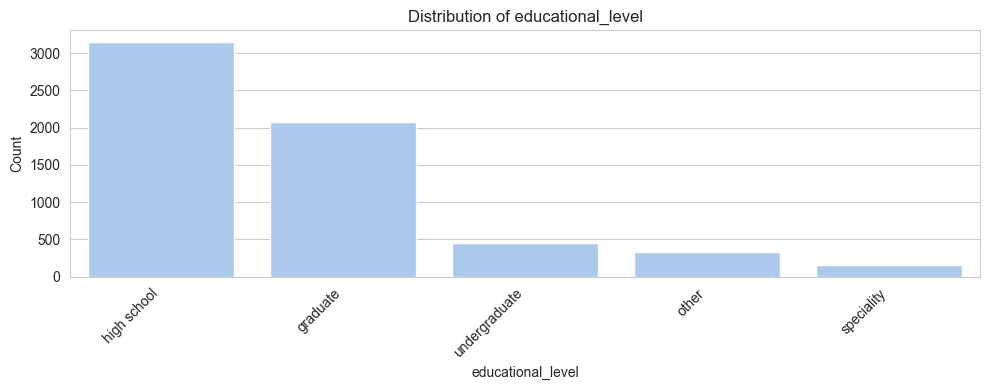

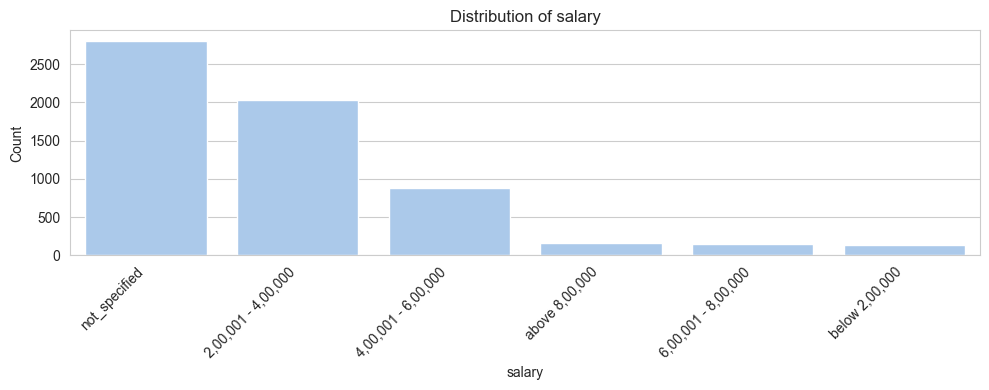

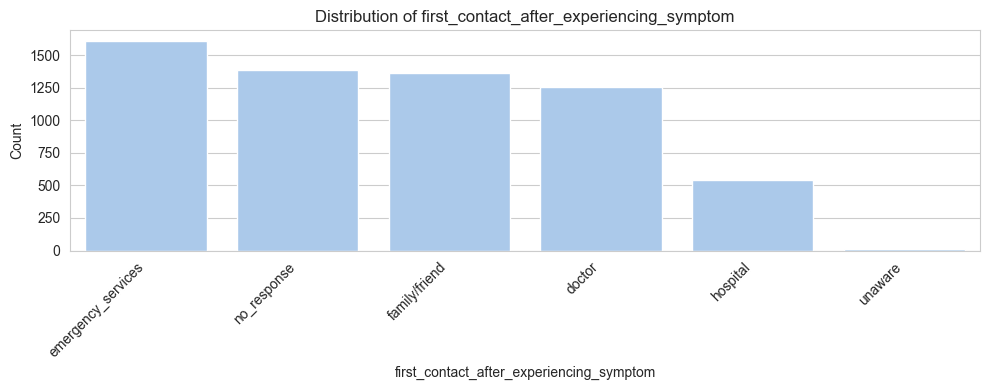

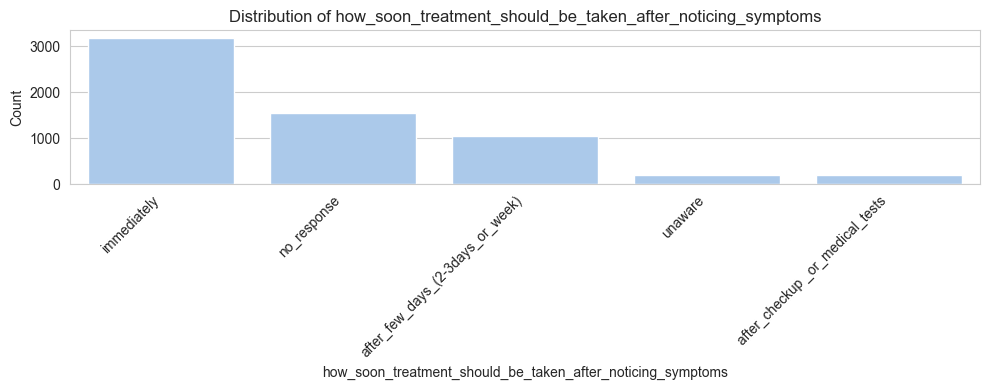

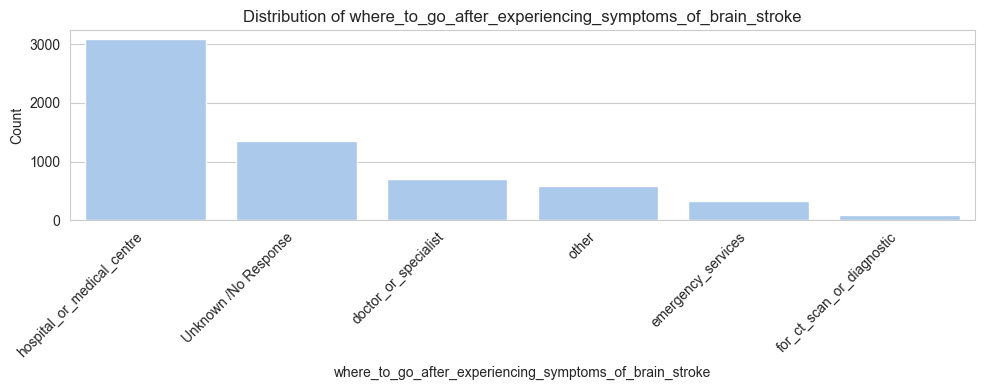

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_7928\1813906350.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


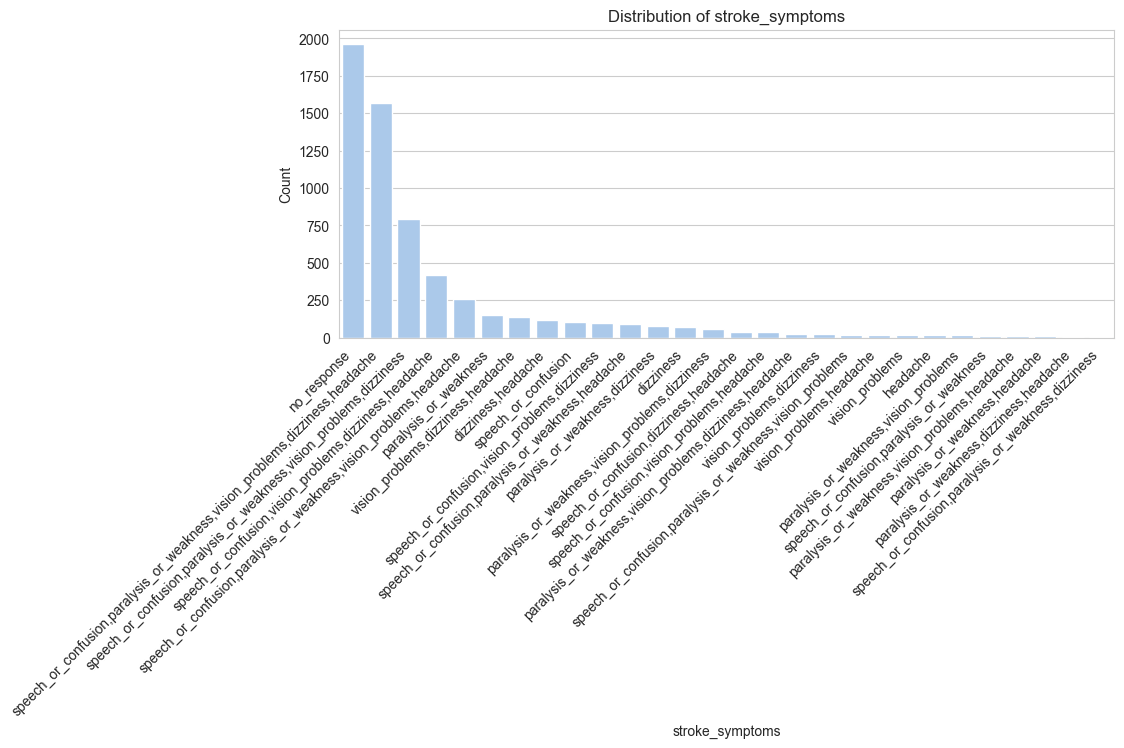

C:\Users\Harshali g\AppData\Local\Temp\ipykernel_7928\1813906350.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


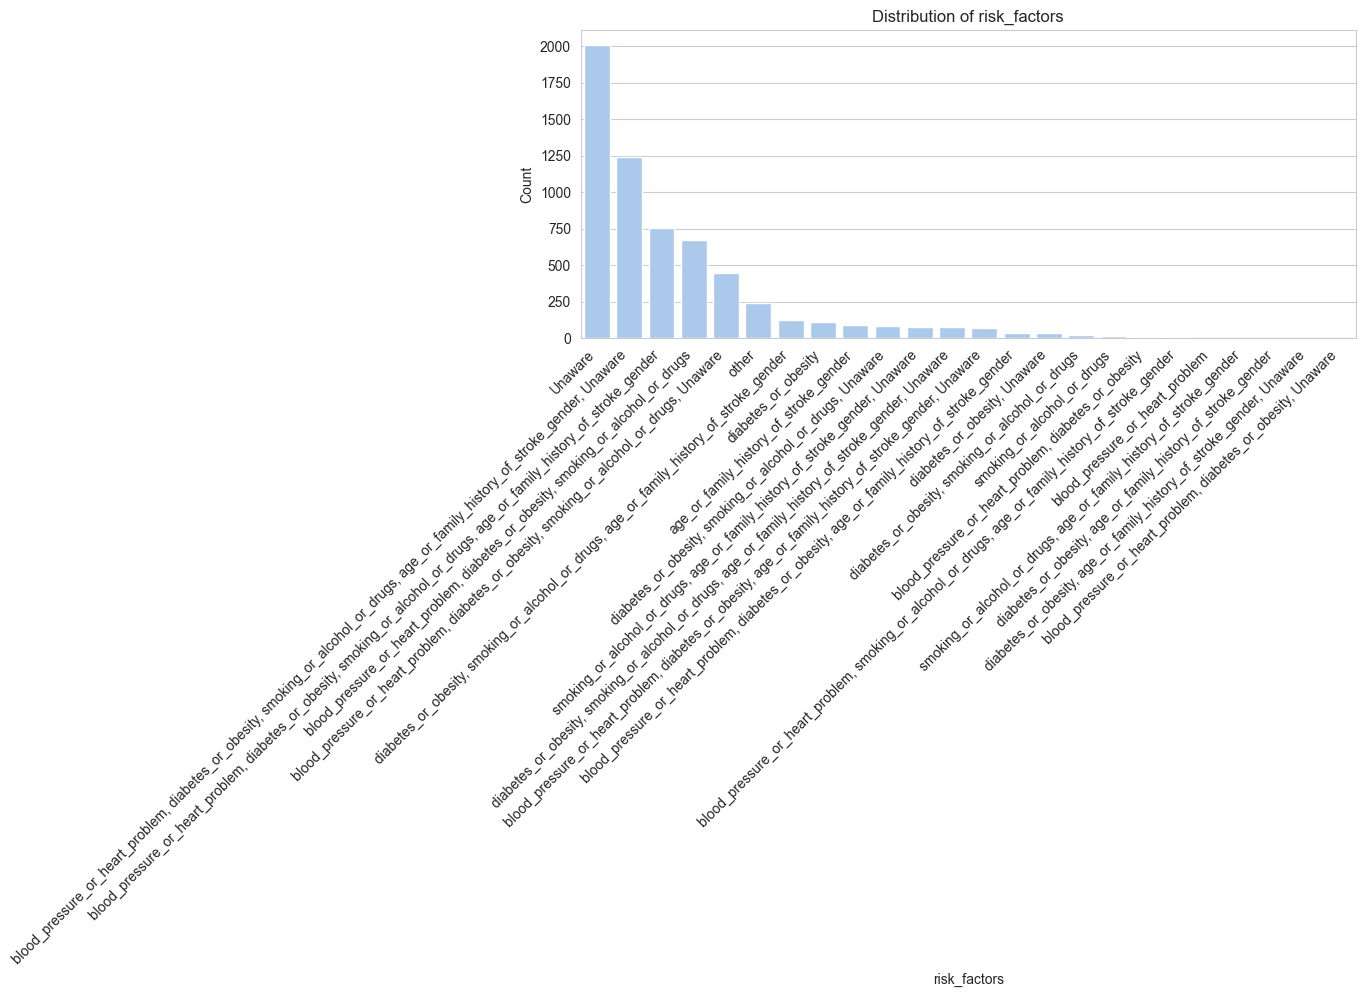

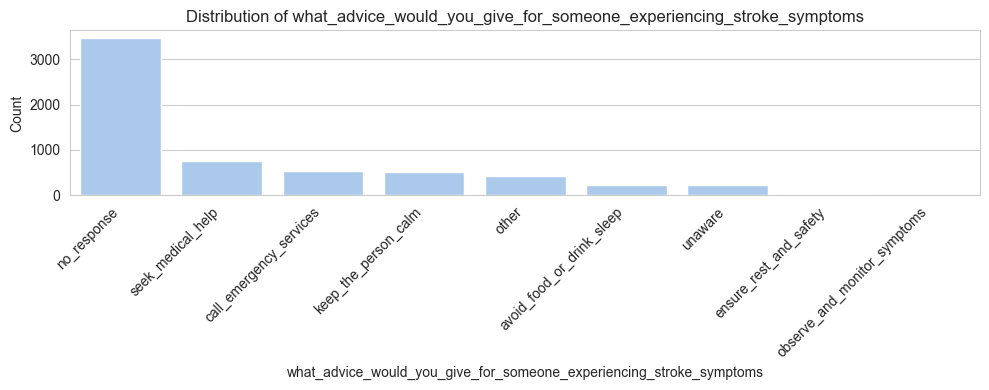

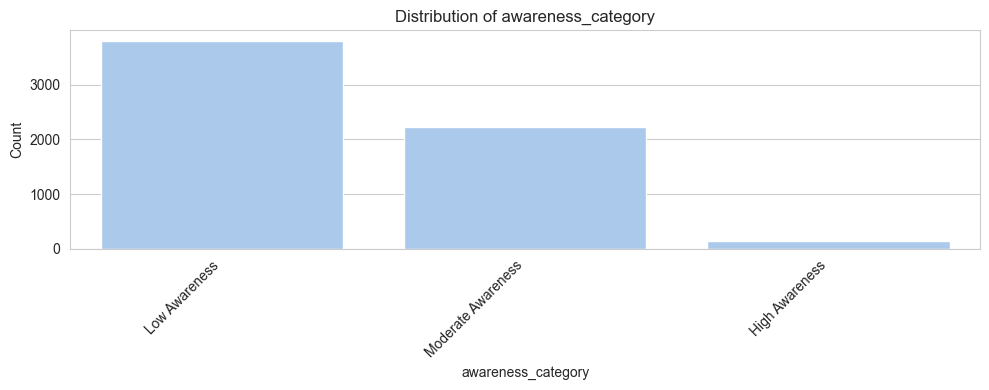

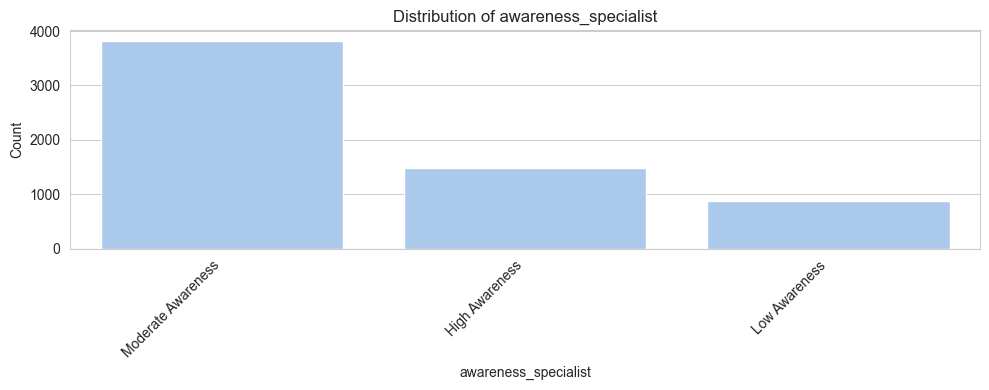

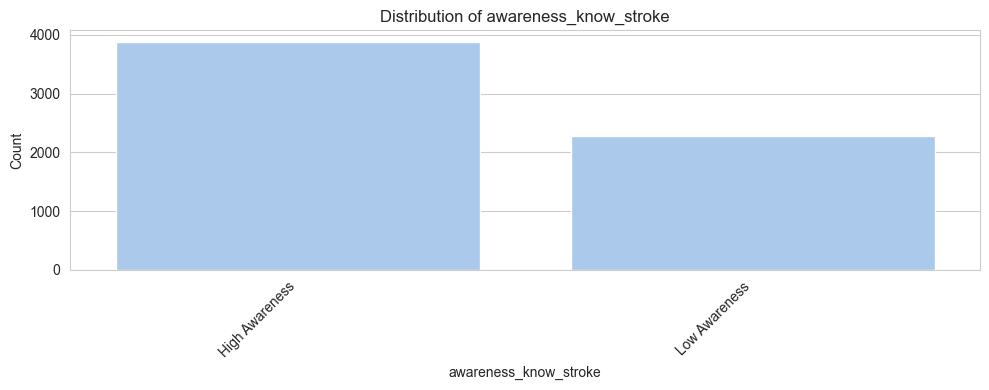

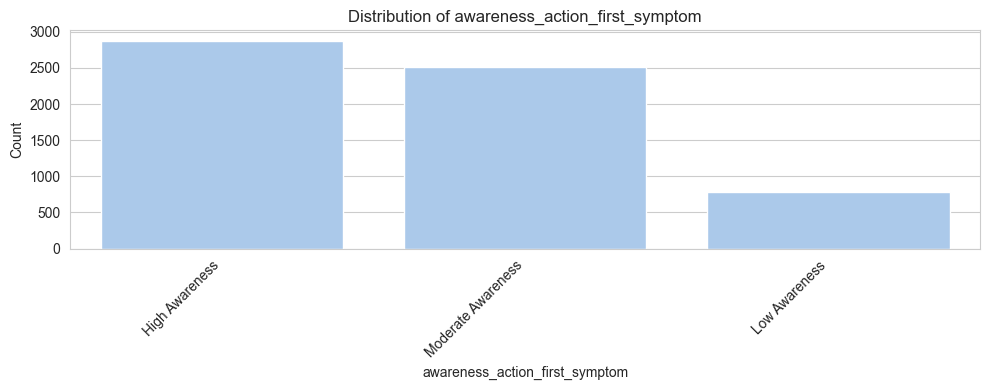

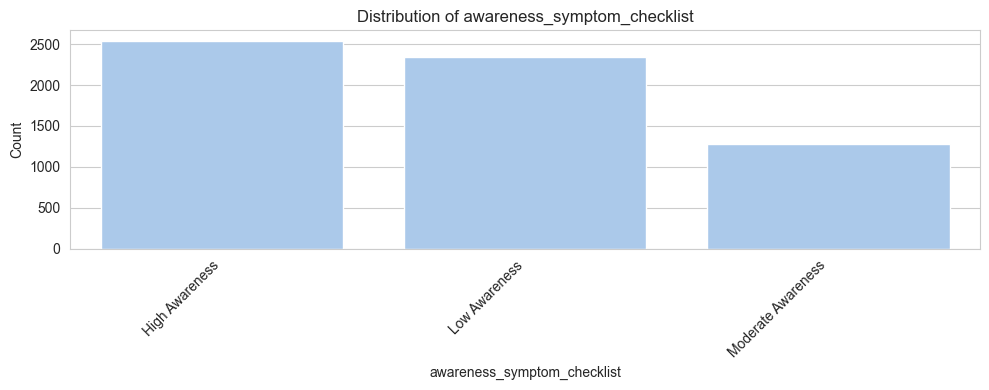

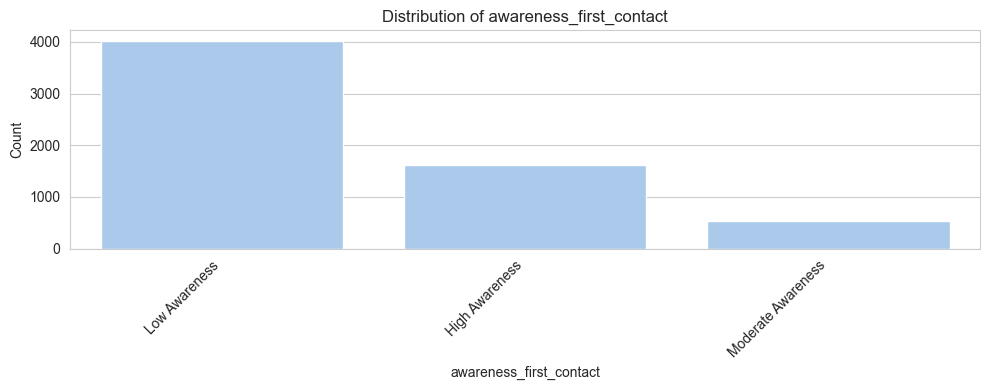

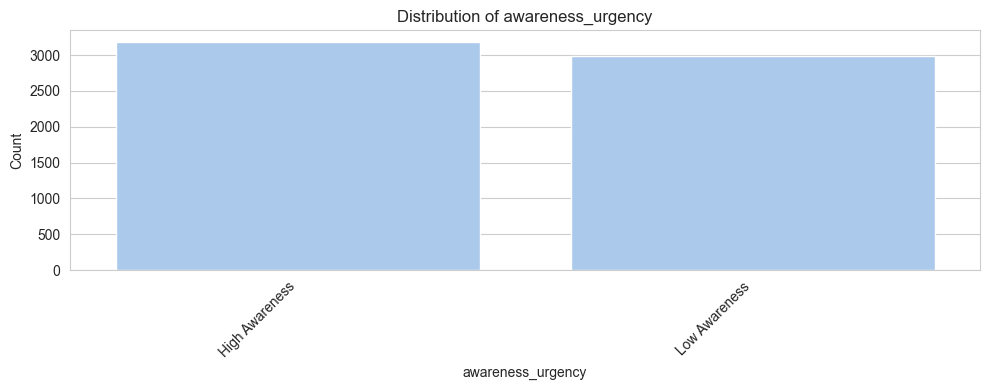

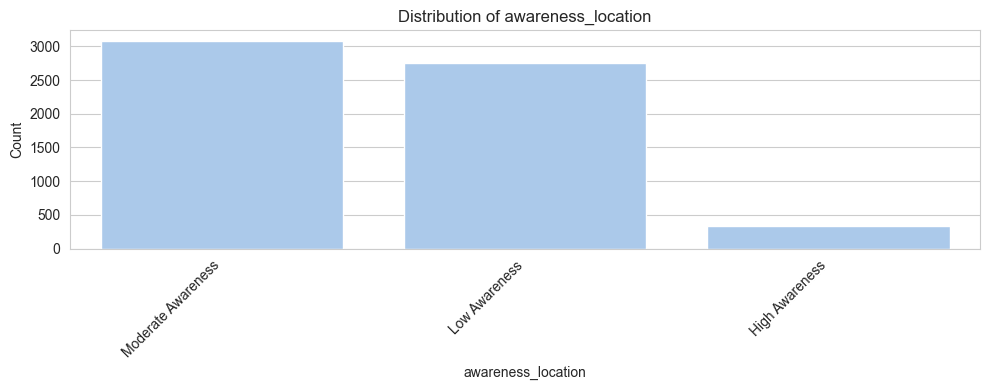

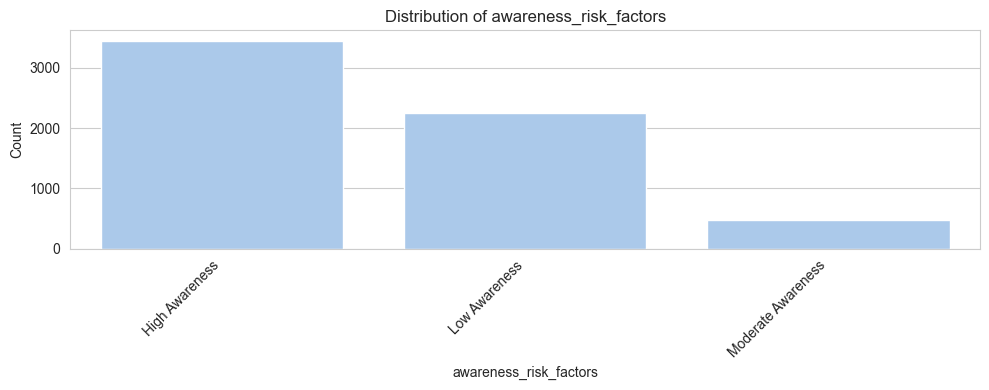

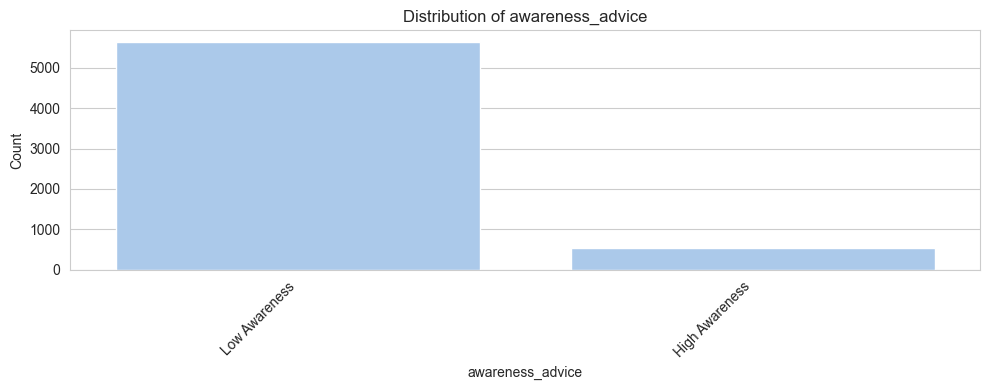

In [31]:
# Select categorical columns only
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical (category-type) columns:")
for c in categorical_cols:
    print("-", c)
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()


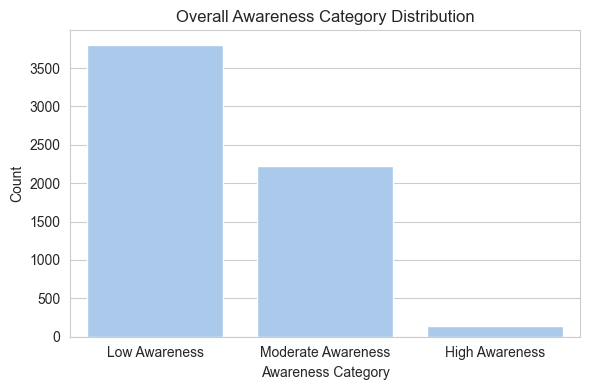

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='awareness_category',
    order=df['awareness_category'].value_counts().index
)
plt.title("Overall Awareness Category Distribution")
plt.xlabel("Awareness Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


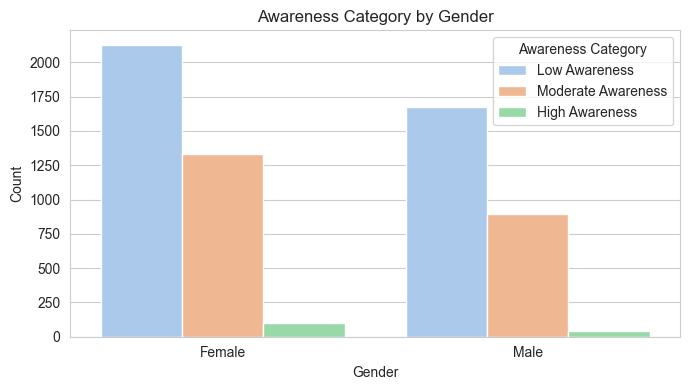

In [33]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x='gender',
    hue='awareness_category',
    order=df['gender'].value_counts().index
)
plt.title("Awareness Category by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Awareness Category")
plt.tight_layout()
plt.show()


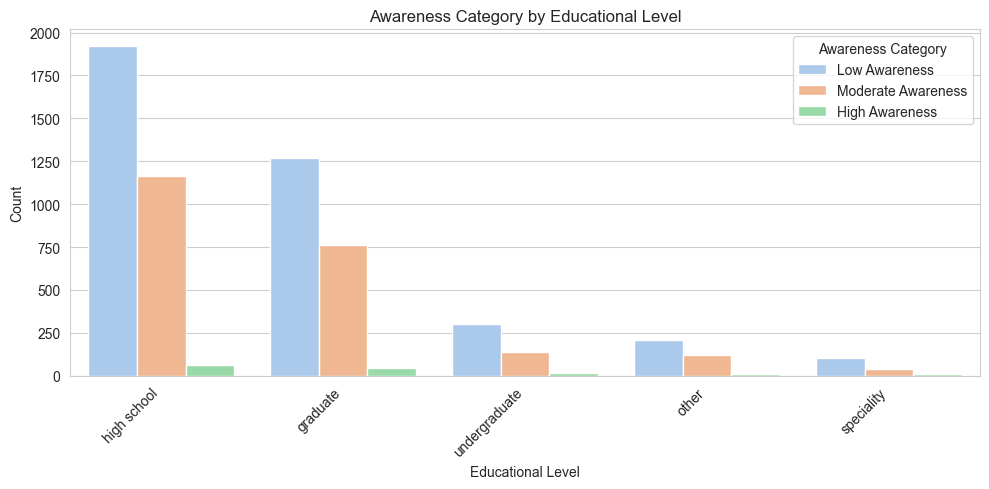

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='educational_level',
    hue='awareness_category',
    order=df['educational_level'].value_counts().index
)
plt.title("Awareness Category by Educational Level")
plt.xlabel("Educational Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Awareness Category")
plt.tight_layout()
plt.show()


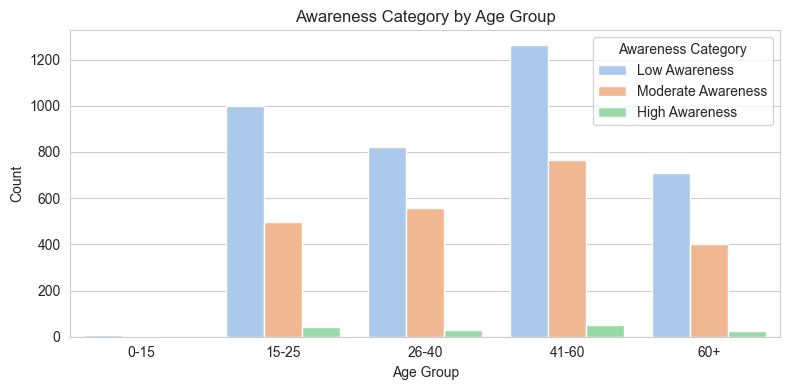

In [35]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='age',
    hue='awareness_category',
    order=df['age'].value_counts().sort_index().index
)
plt.title("Awareness Category by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Awareness Category")
plt.tight_layout()
plt.show()


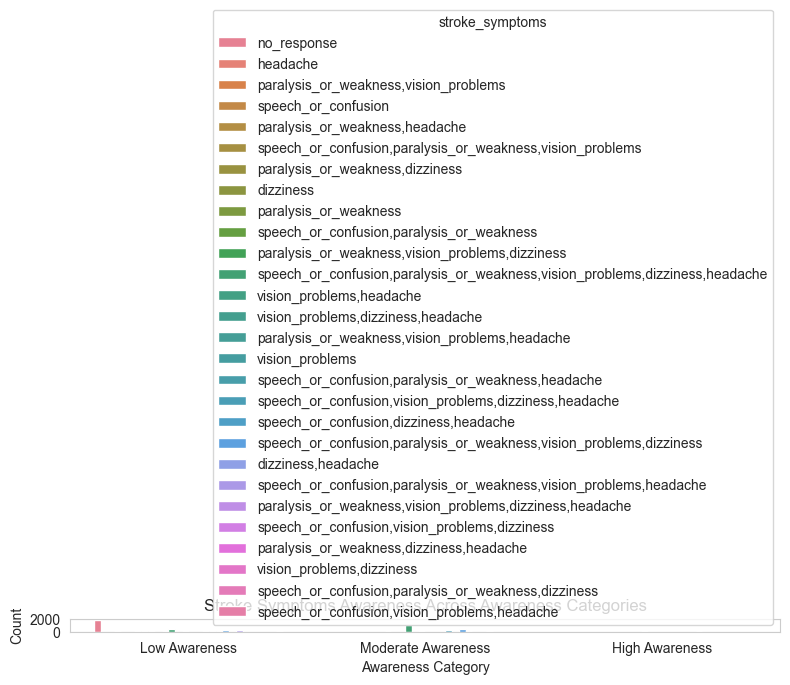

In [36]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='awareness_category',
    hue='stroke_symptoms'
)
plt.title("Stroke Symptoms Awareness Across Awareness Categories")
plt.xlabel("Awareness Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


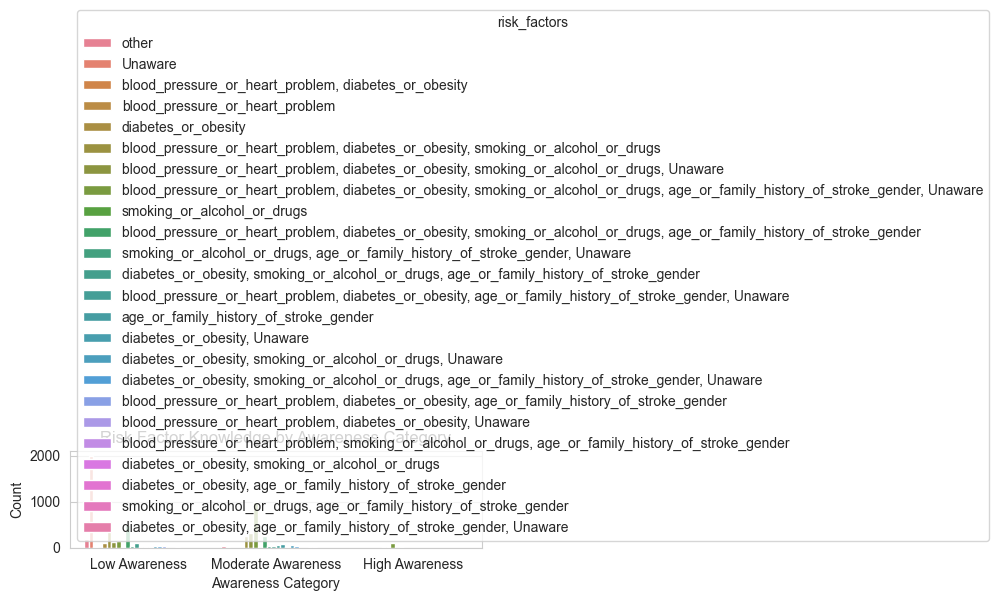

In [37]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=df,
    x='awareness_category',
    hue='risk_factors'
)
plt.title("Risk Factor Knowledge by Awareness Category")
plt.xlabel("Awareness Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


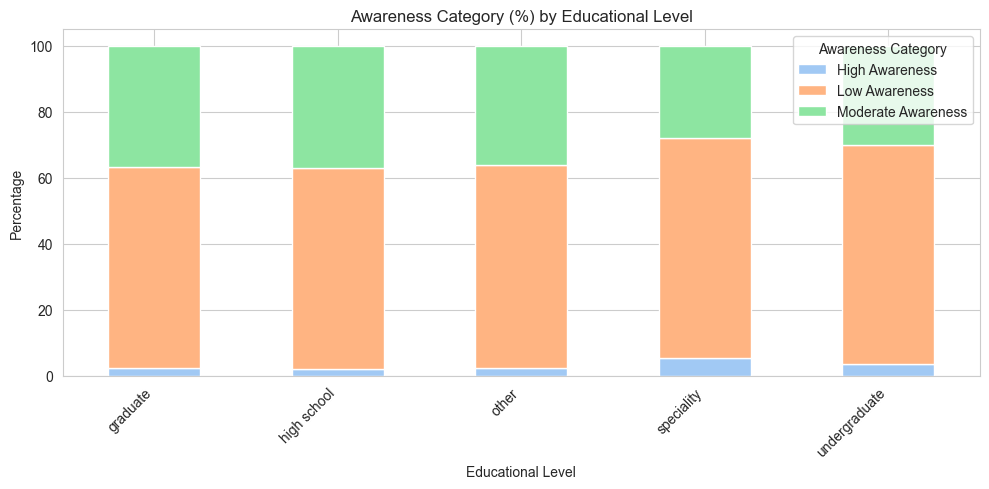

In [38]:
# Awareness vs Education (percentage)
ct = pd.crosstab(df['educational_level'], df['awareness_category'], normalize='index') * 100

ct.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title("Awareness Category (%) by Educational Level")
plt.xlabel("Educational Level")
plt.ylabel("Percentage")
plt.legend(title="Awareness Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:

# Fixed options (use EXACT survey options)
stroke_options = [
    "speech_or_confusion",
    "paralysis_or_weakness",
    "vision_problems",
    "dizziness",
    "headache",
    "no_response",

]


def presence(series, keyword):
    s = series.fillna("").astype(str)
    return s.str.contains(re.escape(keyword), case=False, regex=True)

records = []

for opt in stroke_options:
    mask = presence(df['stroke_symptoms'], opt)
    temp = df[mask].groupby('awareness_category').size()
    total = df.groupby('awareness_category').size()
    perc = (temp / total * 100).fillna(0)
    for cat in perc.index:
        records.append([opt, cat, perc[cat]])

plot_df = pd.DataFrame(records, columns=["Symptom", "Awareness Category", "Percentage"])


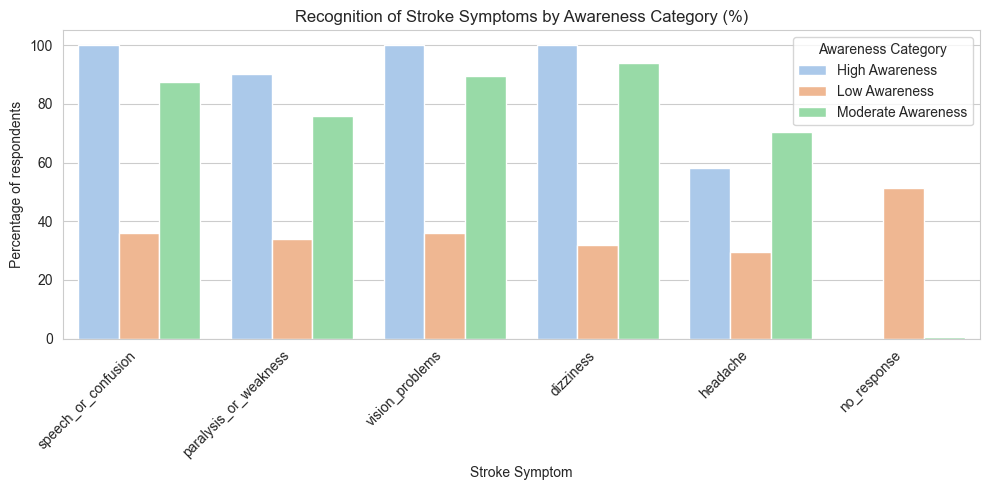

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=plot_df,
    x="Symptom",
    y="Percentage",
    hue="Awareness Category"
)
plt.title("Recognition of Stroke Symptoms by Awareness Category (%)")
plt.ylabel("Percentage of respondents")
plt.xlabel("Stroke Symptom")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


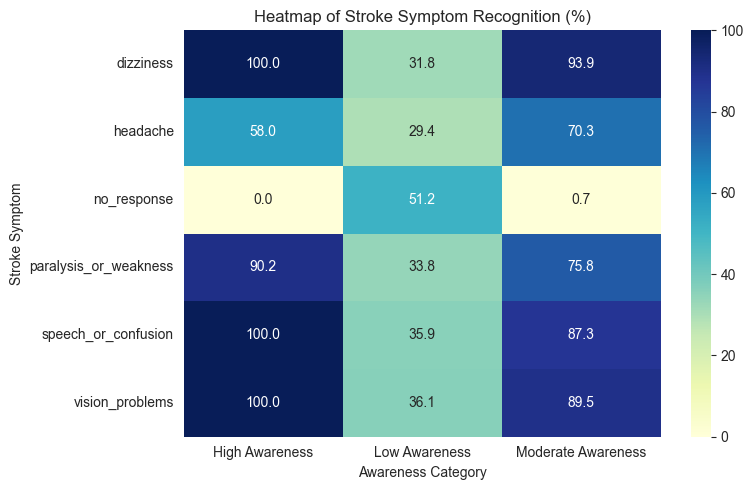

In [41]:
heat_data = plot_df.pivot(
    index="Symptom",
    columns="Awareness Category",
    values="Percentage"
)

plt.figure(figsize=(8,5))
sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Heatmap of Stroke Symptom Recognition (%)")
plt.xlabel("Awareness Category")
plt.ylabel("Stroke Symptom")
plt.tight_layout()
plt.show()


In [52]:
risk_options = [
    "blood_pressure_or_heart_problem",
    "diabetes_or_obesity",
    "smoking_or_alcohol_or_drugs",
    "age_or_family_history_of_stroke_gender",
    "other",
    
    "no_response"
]

records = []

for opt in risk_options:
    mask = presence(df['risk_factors'], opt)
    temp = df[mask]['awareness_category'].value_counts(normalize=True) * 100
    for cat in temp.index:
        records.append([opt, cat, temp[cat]])

risk_df = pd.DataFrame(records, columns=["Risk Factor", "Awareness Category", "Percentage"])


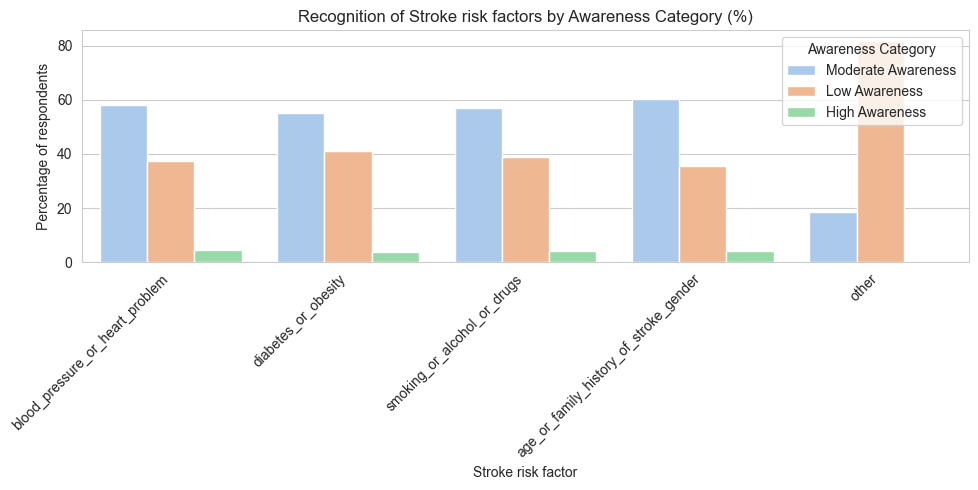

In [56]:
# pivot = risk_df.pivot(
#     index="Risk Factor",
#     columns="Awareness Category",
#     values="Percentage"
# )

# pivot.plot(kind="bar", stacked=True, figsize=(10,5))
# plt.title("Awareness Category Distribution for Risk Factors (%)")
# plt.ylabel("Percentage")
# plt.xlabel("Risk Factor")
# plt.xticks(rotation=45, ha="right")
# plt.legend(title="Awareness Category")
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10,5))
sns.barplot(
    data=risk_df,
    x="Risk Factor",
    y="Percentage",
    hue="Awareness Category"
)
plt.title("Recognition of Stroke risk factors by Awareness Category (%)")
plt.ylabel("Percentage of respondents")
plt.xlabel("Stroke risk factor")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


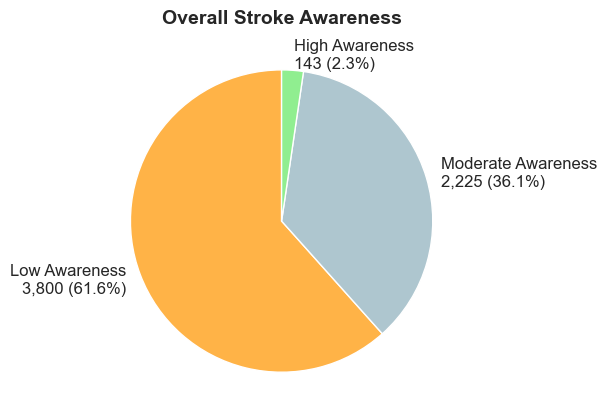

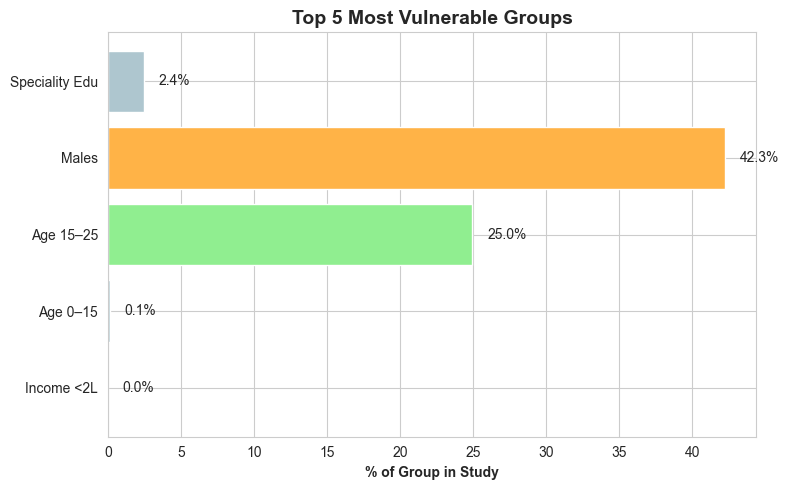

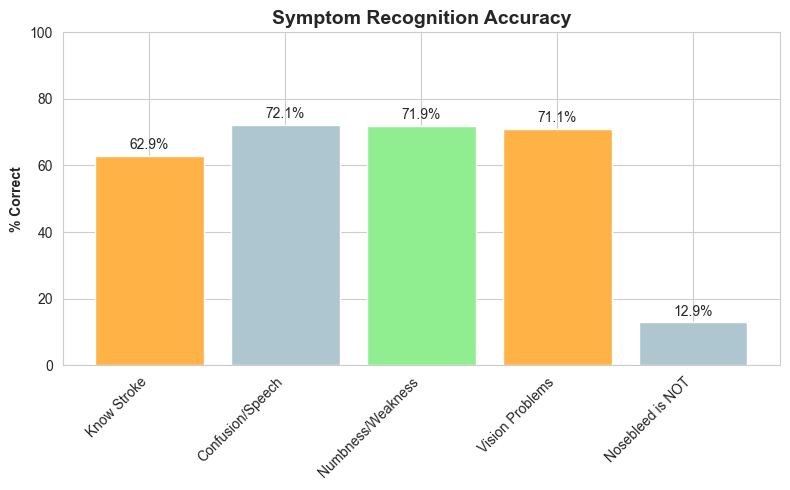

posx and posy should be finite values
posx and posy should be finite values


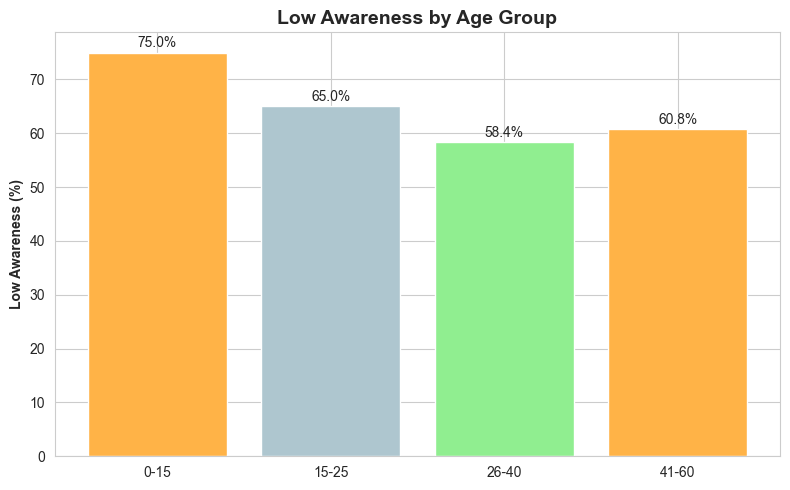

In [44]:
total = len(df)

sns.set_palette("pastel")
sns.set_style("whitegrid")

# 1. Overall Awareness Pie with Insight
category_counts = df['awareness_category'].value_counts()
plt.figure(figsize=(6,6))
colors = ['#FFB347','#AEC6CF','#90EE90']
wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=[f"{cat}\n{count:,} ({count/total*100:.1f}%)" 
            for cat, count in category_counts.items()],
    autopct='', colors=colors, startangle=90, textprops={'fontsize':12}
)
plt.title("Overall Stroke Awareness", fontsize=14, fontweight='bold')
# Insight callout
plt.tight_layout()
plt.show()

# 2. Vulnerable Groups Bar with Insight
vuln = {
    'Income <2L': df[df['salary']=='Below 2,00,000'].shape[0]/total*100,
    'Age 0–15': df[df['age']=='0-15'].shape[0]/total*100,
    'Age 15–25': df[df['age']=='15-25'].shape[0]/total*100,
    'Males': df[df['gender']=='Male'].shape[0]/total*100,
    'Speciality Edu': df[df['educational_level']=='speciality'].shape[0]/total*100
}
plt.figure(figsize=(8,5))
bars = plt.barh(list(vuln.keys()), list(vuln.values()), color=colors[:5])
plt.xlabel("% of Group in Study", fontweight='bold')
plt.title("Top 5 Most Vulnerable Groups", fontsize=14, fontweight='bold')
for bar in bars:
    x = bar.get_width()
    plt.text(x+1, bar.get_y()+bar.get_height()/2, f"{x:.1f}%", va='center')
# Insight

plt.tight_layout()
plt.show()

# 3. Symptom Recognition Accuracy with Insight
symptom_accuracy = {
    'Know Stroke': (df['do_you_know_what_is_a_brain_stroke?']=='Yes').mean()*100,
    'Confusion/Speech': (df.iloc[:,3]=='yes').mean()*100,
    'Numbness/Weakness': (df.iloc[:,4]=='yes').mean()*100,
    'Vision Problems': (df.iloc[:,6]=='yes').mean()*100,
    'Nosebleed is NOT': (df.iloc[:,5]=='no').mean()*100
}
plt.figure(figsize=(8,5))
bars = plt.bar(list(symptom_accuracy.keys()), list(symptom_accuracy.values()), color=colors)
plt.ylim(0,100)
plt.ylabel("% Correct", fontweight='bold')
plt.title("Symptom Recognition Accuracy", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+2, f"{y:.1f}%", ha='center')
# Insight

plt.tight_layout()
plt.show()

# 4. Low Awareness % by Age with Dual Insight
age_low = pd.crosstab(df['age'], df['awareness_category'], normalize='index')['Low Awareness']*100
order = ['0-15','15-25','26-40','41-60','Other']
age_low = age_low.reindex(order)
plt.figure(figsize=(8,5))
bars = plt.bar(order, age_low.values, color=colors)
plt.ylabel("Low Awareness (%)", fontweight='bold')
plt.title("Low Awareness by Age Group", fontsize=14, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+1, f"{h:.1f}%", ha='center')
# Dual insight

plt.tight_layout()
plt.show()
